##### RNN Long Dependencies

##### Dataset
x_t​=0.15x_t−1 ​+ 0.85x_t−gap ​+ noise. 
The series depends on short-term memory x_t−1, and long-term memory x_t−gap.


In [77]:

def make_long_dependency_series(T=1500, gap=5, noise_std=0.05, seed=42):
    rng = np.random.default_rng(seed)
    x = np.zeros(T, dtype=np.float32) #Creates an array of length T filled with zeros.

    # init first gap points
    x[:gap] = rng.normal(0, 1, size=gap).astype(np.float32) #Fills the first 'gap' elements of the array 'x' with random numbers drawn from a normal distribution with mean 0 and standard deviation 1.

    # generate the rest of the series
    for t in range(gap, T):
        eps = rng.normal(0, noise_std) #Generates a random noise term 'eps' drawn from a normal distribution with mean 0 and standard deviation 'noise_std'.
        x[t] = 0.15 * x[t-1] + 0.85 * x[t-gap] + eps #Updates the value of x at time t based on a linear combination of the previous value x[t-1], the value gap steps ago x[t-gap], and the noise term eps.
    return x

##### Sliding Window Dataset

In [78]:
def make_sliding_windows(x, W):
    # W: window size
    # X shape: (N, W, 1), y shape: (N, 1) 
    X, y = [], []

    # Predict the next value from the last W values
    for i in range(len(x) - W):
        X.append(x[i:i+W]) # Appends 'x' from index 'i' to 'i+W' (exclusive) to the list 'X'. This creates a sliding window of size 'W' that moves through the array 'x'.
        y.append(x[i+W]) # next value after the window
    X = np.array(X, dtype=np.float32)[:, :, None]
    y = np.array(y, dtype=np.float32)[:, None]
    return X, y

# Split the data into train and test sets based on time (no shuffling)
def train_test_split_time(X, y, train_ratio=0.7):
    n = len(X)
    n_train = int(n * train_ratio)
    return X[:n_train], y[:n_train], X[n_train:], y[n_train:]

# Standardize the data based on the training set statistics
def standardize_train_test(Xtr, Xte, ytr, yte):
    # standardize X
    X_mu = Xtr.mean()
    X_sd = Xtr.std() + 1e-8 # add small value to avoid division by zero
    Xtr_s = (Xtr - X_mu) / X_sd
    Xte_s = (Xte - X_mu) / X_sd

    # standardize y
    y_mu = ytr.mean()
    y_sd = ytr.std() + 1e-8 # add small value to avoid division by zero
    ytr_s = (ytr - y_mu) / y_sd
    yte_s = (yte - y_mu) / y_sd

    stats = {"X_mu": X_mu, "X_sd": X_sd, "y_mu": y_mu, "y_sd": y_sd}
    return Xtr_s, Xte_s, ytr_s, yte_s, stats

##### RNN Implementation

In [79]:
class RNN:
    def __init__(self, input_dim=1, hidden_dim=32, seed=42):
        # input_dim: dimensionality of input x_t (1 for our univariate series)
        # hidden_dim: number of hidden units in the RNN
        rng = np.random.default_rng(seed)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Weight init (Xavier-style initialization: to keeps variance stable and prevents exploding/vanishing early)
        # Wx: input to hidden weight
        self.Wx = (rng.normal(0, 1, size=(hidden_dim, input_dim)) / np.sqrt(input_dim)).astype(np.float32)
        # Wh: hidden to hidden weight
        self.Wh = (rng.normal(0, 1, size=(hidden_dim, hidden_dim)) / np.sqrt(hidden_dim)).astype(np.float32)
        # bh:hidden bias
        self.bh = np.zeros((hidden_dim, 1), dtype=np.float32)

        # Wy: hidden to output weight
        self.Wy = (rng.normal(0, 1, size=(1, hidden_dim)) / np.sqrt(hidden_dim)).astype(np.float32)
        # by: output bias
        self.by = np.zeros((1, 1), dtype=np.float32)

    # static methods for activation and its derivative
    # @staticmethod decorator indicates that these methods do not depend on the instance (self) and can be called on the class itself.
    # hiddne activation function
    @staticmethod
    def _tanh(z):
        return np.tanh(z)

    # derivative of tanh with respect to its output h
    @staticmethod
    def _dtanh(h):
        return 1.0 - h * h

    """The forward pass processes a sequence one time step at a time, updating a hidden state 
    that remembers past information and producing outputs. """
    # Process sequence from t = 1 → T
    def forward(self, x_seq):
        """
        x_seq shape: (W, input_dim, 1)
        returns:
          y_hat: (1,1)
          cache: list of (x_t, h_prev, h_t)
        """
        W = x_seq.shape[0]
        # initialize hidden state to zeros
        h_prev = np.zeros((self.hidden_dim, 1), dtype=np.float32)
        # to store intermediate values for backpropagation through time (BPTT)
        cache_steps = []

        for t in range(W):
            x_t = x_seq[t]  # (input_dim,1)

            # compute hidden activation: h_t = tanh(Wx x_t + Wh h_{t-1} + b)
            a_t = self.Wx @ x_t + self.Wh @ h_prev + self.bh
            h_t = self._tanh(a_t)

            # store values for backpropagation
            cache_steps.append((x_t, h_prev, h_t))
            # update h_prev for next step
            h_prev = h_t

        # output from final hidden state: y_hat = Wy h_last + by
        y_hat = self.Wy @ h_prev + self.by
        # need to return cache for all steps and the last hidden state for backprop
        cache = {"steps": cache_steps, "h_last": h_prev}
        return y_hat, cache

    """The backward pass computes gradients of the loss with respect to all weights by propagating errors backward through time."""
    # Send error backward from t = T → 1
    def backward(self, y_hat, y_true, cache):
        """
        Loss: L = 0.5*(y_hat - y_true)^2
        grads computed by BPTT over the W steps.
        """
        steps = cache["steps"]
        W = len(steps)

        # dL/dy_hat -> The gradient of the loss with respect to the predicted output y_hat is computed as (y_hat - y_true). 
        # This is derived from the mean squared error loss function, where the derivative with respect to y_hat is simply 
        # the difference between the predicted value and the true value.
        dy = (y_hat - y_true).astype(np.float32)  # (1,1)

        # The gradient of the loss with respect to the output layer weights Wy is computed as the outer product of the 
        # gradient dy and the last hidden state h_last.
        dWy = dy @ cache["h_last"].T   # (1,H)
        # The gradient of the loss with respect to the output layer bias by is simply the gradient dy, 
        # because the bias is added directly to the output.
        dby = dy                       # (1,1)

        # backprop into last hidden
        dh_next = (self.Wy.T @ dy).astype(np.float32)  # (H,1)

        # init rnn parameter grads
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)

        # backprop through time (BPTT)
        for t in reversed(range(W)):
            # get cached values for this step
            x_t, h_prev, h_t = steps[t]

            # gradient before activation: da = dh_next * dtanh(h_t)
            da = dh_next * self._dtanh(h_t)  # (H,1)
            # gradient for input to hidden weight
            dWx += da @ x_t.T                # (H,In)
            # gradient for hidden to hidden weight
            dWh += da @ h_prev.T             # (H,H)
            # gradient for hidden bias
            dbh += da

            # Pass gradient to previous time
            dh_next = (self.Wh.T @ da).astype(np.float32)

        grads = {"Wx": dWx, "Wh": dWh, "bh": dbh, "Wy": dWy, "by": dby}
        return grads

    @staticmethod
    def _clip_inplace(grads, clip=0.5):
        for k in grads:
            # Clip gradients in-place to the range [-clip, clip] to prevent exploding gradients during training.
            np.clip(grads[k], -clip, clip, out=grads[k]) 

    def step(self, grads, lr=1e-2, clip=0.5):
        self._clip_inplace(grads, clip=clip)

        # Update weights with gradient descent: w = w - lr * dw
        self.Wx -= lr * grads["Wx"]
        self.Wh -= lr * grads["Wh"]
        self.bh -= lr * grads["bh"]
        self.Wy -= lr * grads["Wy"]
        self.by -= lr * grads["by"]

    def fit(self, X_train, y_train, epochs=35, lr=1e-2, clip=0.5, verbose=True):
        """
        X_train: (N, W, 1)
        y_train: (N, 1)
        """
        N = len(X_train)
        losses = []

        for ep in range(1, epochs + 1):
            total = 0.0

            for i in range(N):
                # Build x_seq: (W, input_dim, 1) = (W,1,1)
                x_seq = X_train[i][:, :, None]
                y_true = y_train[i][None, :]  # (1,1)

                # Forward pass
                y_hat, cache = self.forward(x_seq)

                # Compute loss (0.5*MSE) for this sample and accumulate
                loss = 0.5 * float(((y_hat - y_true) ** 2).sum())
                total += loss

                # Backward pass and parameter update
                grads = self.backward(y_hat, y_true, cache)
                self.step(grads, lr=lr, clip=clip)

            # Compute mean loss for this epoch
            mean_loss = total / N
            losses.append(mean_loss)

            # Print progress every 5 epochs
            if verbose and (ep == 1 or ep % 30 == 0):
                print(f"Epoch {ep:3d}/{epochs} | mean loss (0.5*MSE) = {mean_loss:.6f}")

        return np.array(losses, dtype=np.float32)

    def predict(self, X):
        """
        X: (N, W, 1)
        returns preds: (N,1)
        """
        N = len(X)
        preds = np.zeros((N, 1), dtype=np.float32)

        for i in range(N):
            x_seq = X[i][:, :, None]  # (W,1,1)
            y_hat, _ = self.forward(x_seq)
            preds[i, 0] = y_hat[0, 0]

        return preds

##### Metrics +  Plotting

In [80]:
import matplotlib.pyplot as plt

# Mean Squared Error (MSE) is a common metric for regression tasks that measures 
# the average squared difference between predicted values and true values.
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

# Mean Absolute Error (MAE) is a common metric for regression tasks that measures 
# the average absolute difference between predicted values and true values. 
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def plot_pred_vs_true(y_true, y_pred, title, n_points=300):
    n = min(len(y_true), n_points)
    plt.figure()
    plt.plot(y_true[:n], label="Ground Truth")
    plt.plot(y_pred[:n], label="Prediction")
    plt.title(title)
    plt.xlabel("Time index (test subset)")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

##### Run experiments

In [81]:
def run_experiment(W, hidden_dim=32, epochs=35, lr=1e-2, clip=0.5, seed=42):
    
    x = make_long_dependency_series(T=1600, gap=5, noise_std=0.05, seed=seed)
    X, y = make_sliding_windows(x, W=W)
    Xtr, ytr, Xte, yte = train_test_split_time(X, y, train_ratio=0.7)

    # standardize X and y
    Xtr_s, Xte_s, ytr_s, yte_s, stats = standardize_train_test(Xtr, Xte, ytr, yte)

    # train
    model = RNN(input_dim=1, hidden_dim=hidden_dim, seed=seed)
    loss_curve = model.fit(Xtr_s, ytr_s, epochs=epochs, lr=lr, clip=clip, verbose=True)

    # predict (standardized space)
    y_pred_tr_s = model.predict(Xtr_s)
    y_pred_te_s = model.predict(Xte_s)

    # unstandardize predictions for reporting
    y_pred_tr = y_pred_tr_s * stats["y_sd"] + stats["y_mu"]
    y_pred_te = y_pred_te_s * stats["y_sd"] + stats["y_mu"]

    return {
        "W": W,
        "Train_MSE": mse(ytr, y_pred_tr),
        "Train_MAE": mae(ytr, y_pred_tr),
        "Test_MSE": mse(yte, y_pred_te),
        "Test_MAE": mae(yte, y_pred_te),
        "loss_curve": loss_curve,
        "y_true_test": yte,
        "y_pred_test": y_pred_te,
    }

Epoch   1/150 | mean loss (0.5*MSE) = 0.356091
Epoch  30/150 | mean loss (0.5*MSE) = 0.289129
Epoch  60/150 | mean loss (0.5*MSE) = 0.268507
Epoch  90/150 | mean loss (0.5*MSE) = 0.262584
Epoch 120/150 | mean loss (0.5*MSE) = 0.254051
Epoch 150/150 | mean loss (0.5*MSE) = 0.251129
Epoch   1/150 | mean loss (0.5*MSE) = 0.249435
Epoch  30/150 | mean loss (0.5*MSE) = 0.073370
Epoch  60/150 | mean loss (0.5*MSE) = 0.045846
Epoch  90/150 | mean loss (0.5*MSE) = 0.038932
Epoch 120/150 | mean loss (0.5*MSE) = 0.035603
Epoch 150/150 | mean loss (0.5*MSE) = 0.033221

 Table: RNN results on long-dependency series (gap=5)
-----------------------------------------------------
  Memory W |  Train MSE |  Train MAE |   Test MSE |   Test MAE
----------------------------------------------------------------
         2 |   0.048665 |   0.170981 |   0.030699 |   0.144166
         5 |   0.005241 |   0.055622 |   0.020311 |   0.111282


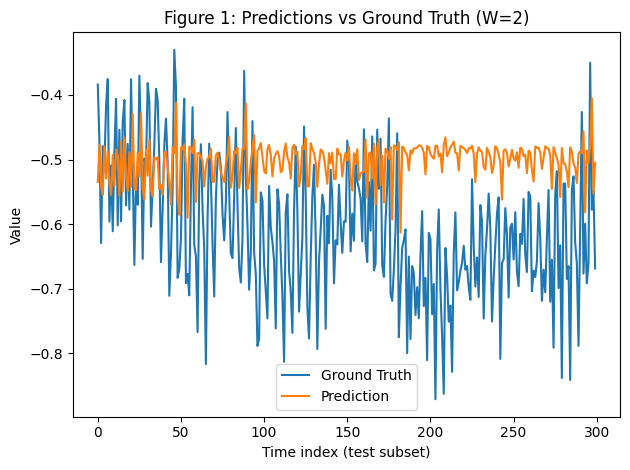

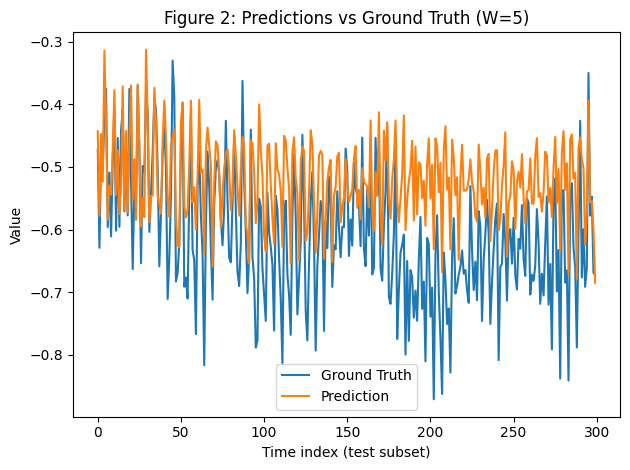

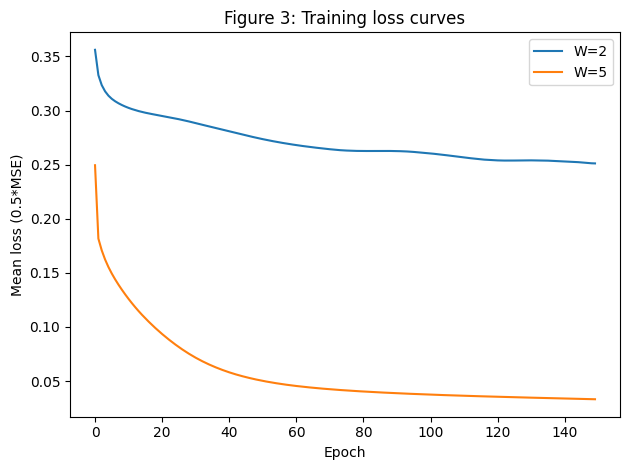

In [82]:
memory_size_2 = run_experiment(W=2, hidden_dim=128, epochs=150, lr=1e-3, clip=0.5, seed=42)
memory_size_5 = run_experiment(W=5, hidden_dim=128, epochs=150, lr=1e-3, clip=0.5, seed=42)

print("\n Table: RNN results on long-dependency series (gap=5)")
print("-----------------------------------------------------")
print(f"{'Memory W':>10} | {'Train MSE':>10} | {'Train MAE':>10} | {'Test MSE':>10} | {'Test MAE':>10}")
print("-" * 64)
for r in [memory_size_2, memory_size_5]:
    print(f"{r['W']:>10} | {r['Train_MSE']:>10.6f} | {r['Train_MAE']:>10.6f} | {r['Test_MSE']:>10.6f} | {r['Test_MAE']:>10.6f}")

plot_pred_vs_true(memory_size_2["y_true_test"], memory_size_2["y_pred_test"], "Figure 1: Predictions vs Ground Truth (W=2)")
plot_pred_vs_true(memory_size_5["y_true_test"], memory_size_5["y_pred_test"], "Figure 2: Predictions vs Ground Truth (W=5)")

plt.figure()
plt.plot(memory_size_2["loss_curve"], label="W=2")
plt.plot(memory_size_5["loss_curve"], label="W=5")
plt.title("Figure 3: Training loss curves")
plt.xlabel("Epoch")
plt.ylabel("Mean loss (0.5*MSE)")
plt.legend()
plt.tight_layout()
plt.show()

##### Discussion + Reflection
Discuss whether long dependencies were captured.
Your synthetic sequence was designed to contain long-range dependencies. Explain whether your RNN truly learned those dependencies or mainly captured
short-term patterns. What evidence from your predictions or plots supports your conclusion? If
you increased the dependency gap further, what do you expect would happen and why?


The synthetic sequence was generated with a long-range dependency of gap = 5, meaning the current value depends strongly on the value 5 time steps earlier. 

**For memory size W =2**
From table result, the model has higher error (Test MSE = 0.0307) compared to W=5. In figure 1, the predictions are relatively smooth and stay close to the mean, and do not follow the large fluctuations of the ground truth. In figure 3, the mean loss remain relatively high. It indicates that RNN with memory size W=2 do not successfully learn this long-term dependency. Instead, it mainly captured short-term trends. 

**For memory size W=5**
From table result, the model has lower error (Test MSE = 0.02031) compared to W=2. In figure 2, the predicitons show better alignment with the ground truth. In figure 3, the training mean loss decreases much faster and reaches a much lower value compared to W=2. It suggests that when the memory size matches the dependency gap, the RNN can learn the long-range dependency. However, the predicitons on W=5 are still smoother than the true signal, meaning that the model still rely partly on short-term patterns and does not perfectly model the long-range relationship.

If the dependency gap is increased further, I expect model's performance will drop significantly unless the memory size is increased accordingly. A larger dependency gap means the model retains information over a longer time. That is difficult for RNN becasue of its limited memory capacity and issues such as vanishing gradients. I also expect that the predictions will be smooth or stay close to the mean, and the MSE will increase.